### 9. Genomför en klustringanalys på datasetet som du hittar [här](https://www.kaggle.com/datasets/thebumpkin/1980s-classic-hits-with-spotify-data)


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [3]:
df = pd.read_csv("1980sClassics.csv")
df

,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
993,When I Looked At Him,Exposé,4:19,4,0.455,0.713,8,-10.959,1,0.0423,0.23000,0.000332,0.3700,0.469,169.633,24,1989
994,I Remember Holding You,Boys Club,4:53,4,0.609,0.843,2,-7.973,0,0.0447,0.30700,0.000598,0.0517,0.762,92.480,19,1989
995,Don’t Rush Me,Taylor Dayne,4:32,4,0.686,0.847,7,-7.692,1,0.2840,0.44500,0.000000,0.2500,0.748,90.793,15,1989
996,I’ll Be Loving You (FOREVER),New Kids on the Block,6:04,4,0.371,0.710,11,-6.437,1,0.0481,0.09640,0.000000,0.7400,0.223,135.003,15,1989


In [5]:
print(f'Rader och kolumner: {df.shape}')
print(f'Saknade värden: {df.isna().sum().sum()}')
display(df.head())

Rader och kolumner: (998, 17)
Saknade värden: 0


,Track,Artist,Duration,Time_Signature,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
0,Babe,Styx,3:38,4,0.700,0.582,11,-5.960,0,0.0356,0.05020,0.000000,0.0881,0.785,116.712,96,1980
1,The Rose,Bette Midler,4:04,4,0.264,0.640,8,-6.221,1,0.0442,0.03930,0.000002,0.1510,0.190,84.828,92,1980
2,Cars,Gary Numan,4:08,4,0.338,0.562,9,-7.181,1,0.0290,0.03900,0.000000,0.1070,0.259,149.907,82,1980
3,Magic,Olivia Newton-John,2:17,4,0.911,0.689,1,-6.176,1,0.2650,0.00119,0.000000,0.0704,0.546,140.034,80,1980
4,We Don’t Talk Anymore,Cliff Richard,3:37,4,0.728,0.563,1,-8.053,0,0.1340,0.62100,0.000000,0.1790,0.352,100.017,80,1980


## Välj variabler för klustringen

Jag klustrar låtarna utifrån deras ljudegenskaper. `Track`, `Artist` och `Duration` är identifierande eller textbaserade variabler och används därför inte i modellen. `Popularity` och `Year` sparas för att analysera klustren efteråt, men används inte för att skapa dem.

In [6]:
audio_features = [
    'Danceability',
    'Energy',
    'Loudness',
    'Speechiness',
    'Acousticness',
    'Instrumentalness',
    'Liveness',
    'Valence',
    'Tempo',
]

X = df[audio_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Variabler som används:', audio_features)
print('Form på den skalade matrisen:', X_scaled.shape)


Variabler som används: ['Danceability', 'Energy', 'Loudness', 'Speechiness', 'Acousticness', 'Instrumentalness', 'Liveness', 'Valence', 'Tempo']
Form på den skalade matrisen: (998, 9)


## Jämför antal kluster

Jag testar flera värden på `k`. Inertia visar klustrens totala avstånd till sina centrum, medan silhouette score visar hur väl låtarna är separerade. Ett högre silhouette score är bättre.

Utvärdering av antal kluster:


,antal_kluster,inertia,silhouette_score
0,2,7243.908,0.234
1,3,6466.050,0.167
2,4,5757.261,0.188
3,5,5150.011,0.193
4,6,4733.684,0.186
5,7,4372.894,0.172
6,8,4080.628,0.174


Högst silhouette score: 2 kluster (0.234)


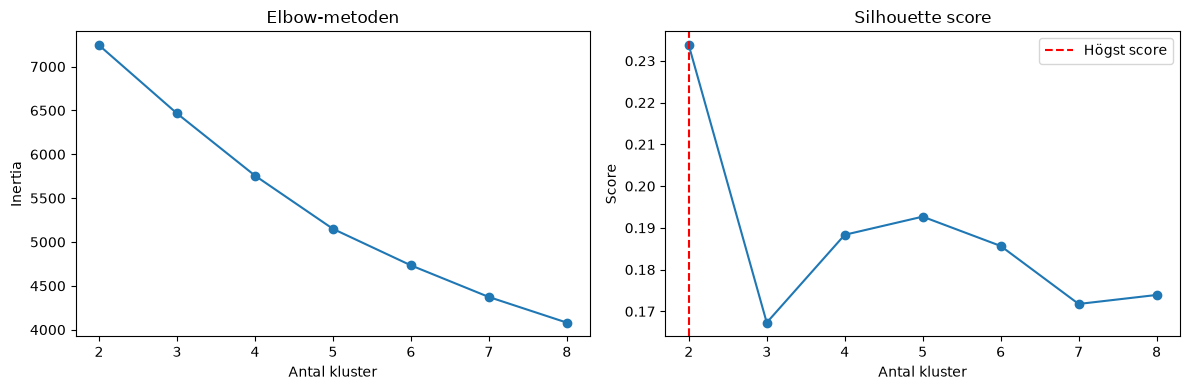

In [7]:
results = []

for cluster_count in range(2, 9):
    model = KMeans(n_clusters=cluster_count, n_init=20, random_state=42)
    labels = model.fit_predict(X_scaled)
    results.append({
        'antal_kluster': cluster_count,
        'inertia': model.inertia_,
        'silhouette_score': silhouette_score(X_scaled, labels),
    })

results_df = pd.DataFrame(results)
best_row = results_df.loc[results_df['silhouette_score'].idxmax()]

print('Utvärdering av antal kluster:')
display(results_df.round(3))
print(
    f"Högst silhouette score: {int(best_row['antal_kluster'])} kluster "
    f"({best_row['silhouette_score']:.3f})"
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(results_df['antal_kluster'], results_df['inertia'], marker='o')
axes[0].set(title='Elbow-metoden', xlabel='Antal kluster', ylabel='Inertia')
axes[1].plot(
    results_df['antal_kluster'],
    results_df['silhouette_score'],
    marker='o',
)
axes[1].axvline(
    best_row['antal_kluster'],
    color='red',
    linestyle='--',
    label='Högst score',
)
axes[1].set(
    title='Silhouette score',
    xlabel='Antal kluster',
    ylabel='Score',
)
axes[1].legend()
plt.tight_layout()
plt.show()


## Träna slutmodellen och tolka klustren

Silhouette score väljer två kluster. Klusternumren är bara etiketter och innebär inte att det ena klustret är bättre än det andra.

In [8]:
best_k = int(best_row['antal_kluster'])
final_model = KMeans(n_clusters=best_k, n_init=20, random_state=42)
df['cluster'] = final_model.fit_predict(X_scaled)

cluster_sizes = df['cluster'].value_counts().sort_index().rename('antal_låtar')
profile = df.groupby('cluster')[audio_features + ['Popularity', 'Year']].mean().round(2)

print(f'Vald modell: KMeans med {best_k} kluster')
print('Antal låtar per kluster:')
display(cluster_sizes.to_frame())
print('Genomsnittliga värden per kluster:')
display(profile)

for cluster_number in sorted(df['cluster'].unique()):
    print(f'\nMest populära låtar i kluster {cluster_number}:')
    display(
        df.loc[df['cluster'] == cluster_number, ['Track', 'Artist', 'Popularity']]
        .sort_values('Popularity', ascending=False)
        .head(5)
    )


Vald modell: KMeans med 2 kluster
Antal låtar per kluster:


,antal_låtar
cluster,
0,303
1,695


Genomsnittliga värden per kluster:


,Danceability,Energy,Loudness,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo,Popularity,Year
cluster,,,,,,,,,,,
0,0.53,0.42,-11.55,0.04,0.49,0.07,0.16,0.37,118.49,55.22,1984.27
1,0.67,0.73,-7.73,0.06,0.14,0.03,0.19,0.71,121.96,58.84,1984.60



Mest populära låtar i kluster 0:


,Track,Artist,Popularity
1,The Rose,Bette Midler,92
299,My Love,Lionel Richie,89
300,Every Breath You Take,The Police,88
101,I Love You,Climax Blues Band,88
599,I’m Your Man,Wham!,86



Mest populära låtar i kluster 1:


,Track,Artist,Popularity
0,Babe,Styx,96
399,Cruel Summer,Bananarama,93
100,Together,Tierra,92
200,Do I Do,Stevie Wonder,91
699,Control,Janet Jackson,91


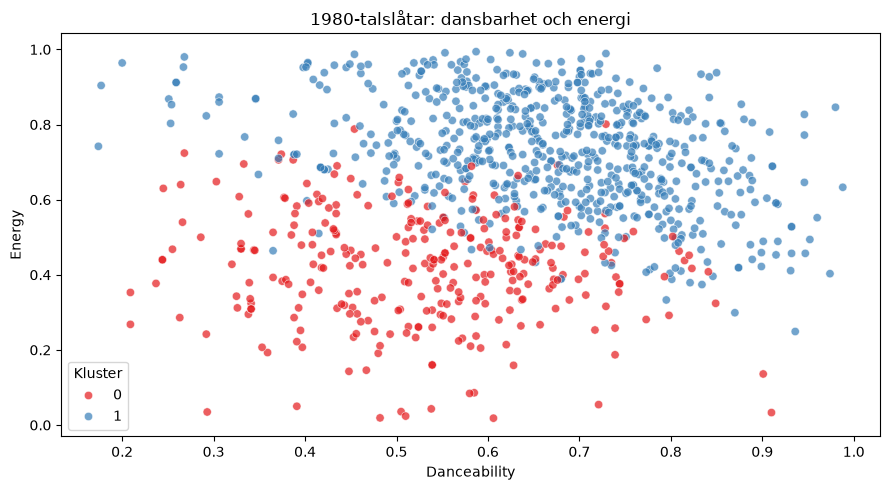

In [9]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=df,
    x='Danceability',
    y='Energy',
    hue='cluster',
    palette='Set1',
    alpha=0.7,
)
plt.title('1980-talslåtar: dansbarhet och energi')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.legend(title='Kluster')
plt.tight_layout()
plt.show()


## Praktisk användning

Klustren kan användas för att skapa musikprofiler, till exempel en mer dansbar och energisk profil jämfört med en lugnare eller mer akustisk profil. En streamingtjänst kan använda profilerna för rekommendationer, spellistor och marknadsföring. En arrangör kan också jämföra vilka musikprofiler som passar olika målgrupper eller evenemang.

`Popularity` och `Year` används här endast för att beskriva klustren i efterhand. Därför kan vi se om en musikprofil historiskt varit mer populär eller om den domineras av vissa år, utan att dessa variabler bestämmer klustertillhörigheten. Klustren visar likheter, inte säkra orsaker till varför en låt blev populär.